<a href="https://colab.research.google.com/github/aakashkumar089/Class-notes/blob/main/OTS_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Supervised Machine learning algorithem used for classification problems.

### It predicts the probability of a class

---



---



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/hearing_test.csv")

In [ ]:
df.head()

#1 ->Test Passed
#0 ->  Not passed

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


## Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [ ]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [ ]:
df.shape

(5000, 3)

In [ ]:
df['test_result'].value_counts()

,count
test_result,
1,3000
0,2000


<Axes: xlabel='test_result', ylabel='count'>

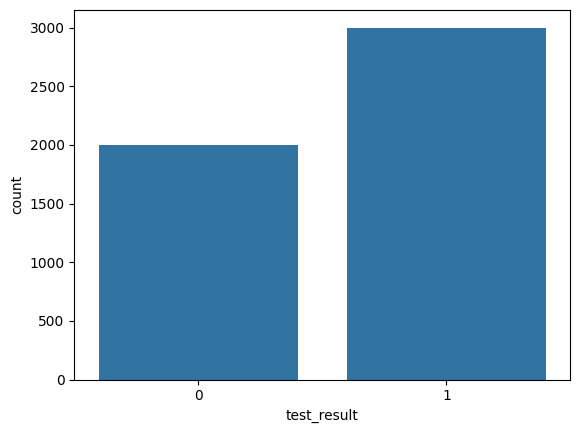

In [ ]:
sns.countplot(data=df,x = "test_result")

<Axes: xlabel='test_result', ylabel='age'>

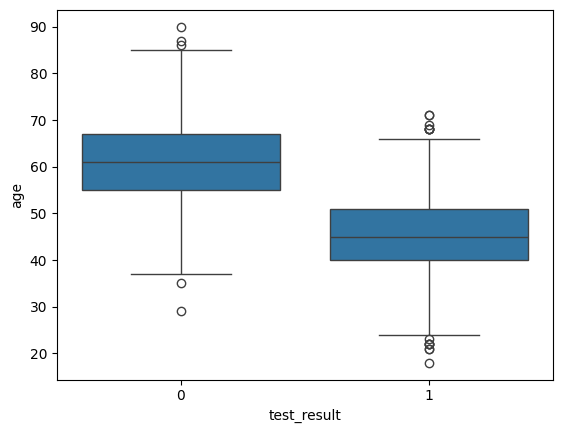

In [ ]:
sns.boxplot(x = 'test_result', y = 'age',data=df)



<Axes: xlabel='test_result', ylabel='physical_score'>

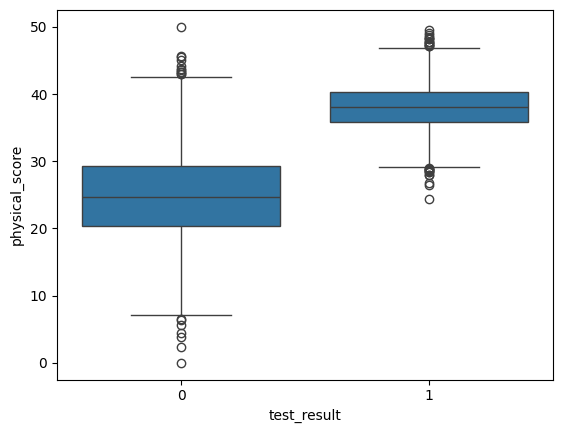

In [ ]:
sns.boxplot(x = 'test_result',y = "physical_score", data=df)

<Axes: xlabel='age', ylabel='physical_score'>

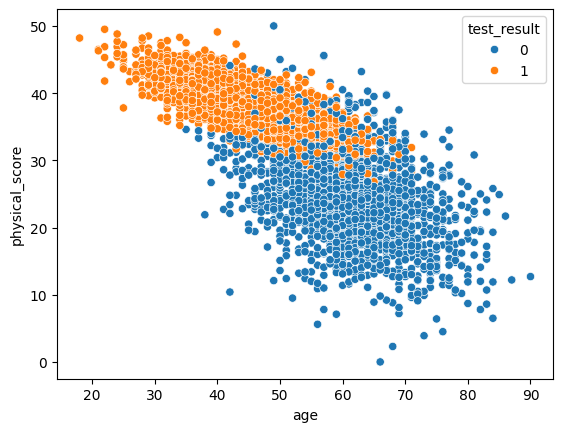

In [ ]:
sns.scatterplot(x='age',y="physical_score",data=df,hue='test_result')

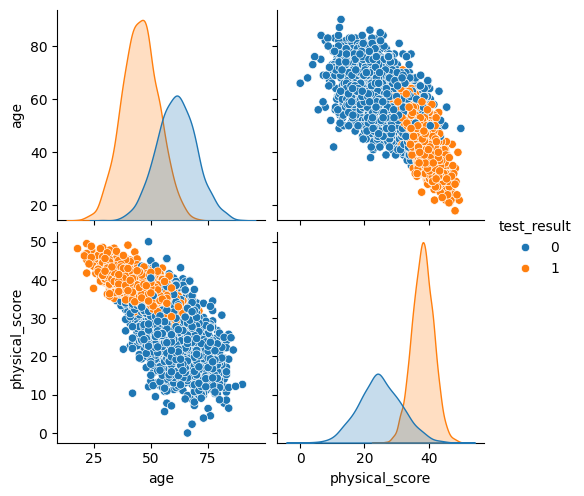

In [ ]:
sns.pairplot(df,hue= 'test_result')

<Axes: >

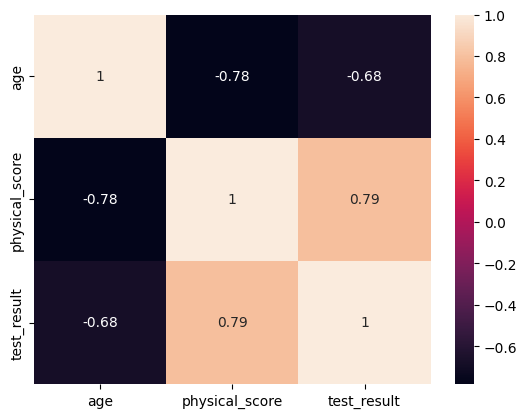

In [ ]:
sns.heatmap(df.corr(),annot=True)

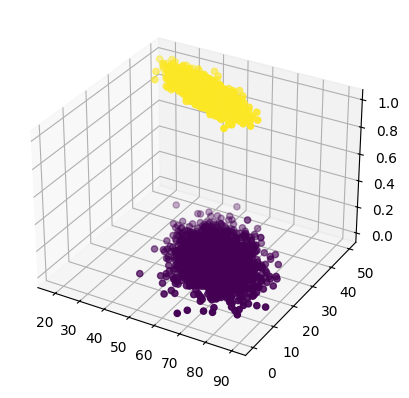

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['age'],df['physical_score'],df['test_result'], c = df['test_result'])

In [ ]:
# Train Test Split

X = df.drop("test_result",axis=1)

y = df['test_result']

In [ ]:
X.head()

,age,physical_score
0,33.0,40.7
1,50.0,37.2
2,52.0,24.7
3,56.0,31.0
4,35.0,42.9


In [ ]:
y.head()

,test_result
0,1
1,1
2,0
3,0
4,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=101)

In [ ]:
scaler = StandardScaler()

## fit() --> evaluvate MEAN and STANDARD DEVIATION
## tranform --> Using Mean and Standard Deviation --> transform into Z score

In [ ]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [ ]:
scaled_X_train

array([[ 0.81634768, -0.81133359],
       [-0.77890358, -0.18429662],
       [ 0.19597219, -0.19659146],
       ...,
       [ 1.17084796, -1.41378088],
       [ 2.76609922, -1.05723045],
       [-1.93102949,  1.18043092]])

In [ ]:
scaled_X_test

array([[-1.13340386,  0.627163  ],
       [-0.60165344,  0.73781658],
       [ 0.37322233, -1.34001183],
       ...,
       [-0.86752865,  0.70093205],
       [ 0.01872205, -0.97116655],
       [ 0.19597219,  0.27061256]])

## Applying Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_model = LogisticRegression()

In [ ]:
log_model.fit(scaled_X_train,y_train)

LogisticRegression()

In [ ]:
log_model.coef_

array([[-0.9039212 ,  3.48681952]])

In [ ]:
log_model.intercept_

array([0.47855828])

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
y_pred = log_model.predict(scaled_X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.917

In [ ]:
confusion_matrix(y_test,y_pred)

array([[332,  56],
       [ 27, 585]])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       388
           1       0.91      0.96      0.93       612

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.92      0.92      1000

